In [1]:
import gymnasium as gym
import highway_env
from stable_baselines3 import PPO
from tqdm import trange

gym.register_envs(highway_env)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# Cell for loading experiments from eval_merge_ppop.py
import numpy as np
NUM_EPISODES = 100000  # Hardcoded for now
successes = NUM_EPISODES - 1994
failures = 1994
p_fail = failures / NUM_EPISODES

collision_positions = np.load("collision_positions.npy").tolist()
collision_speeds = np.load("collision_speeds.npy").tolist()
collision_types = np.load("collision_types.npy", allow_pickle=True).tolist()

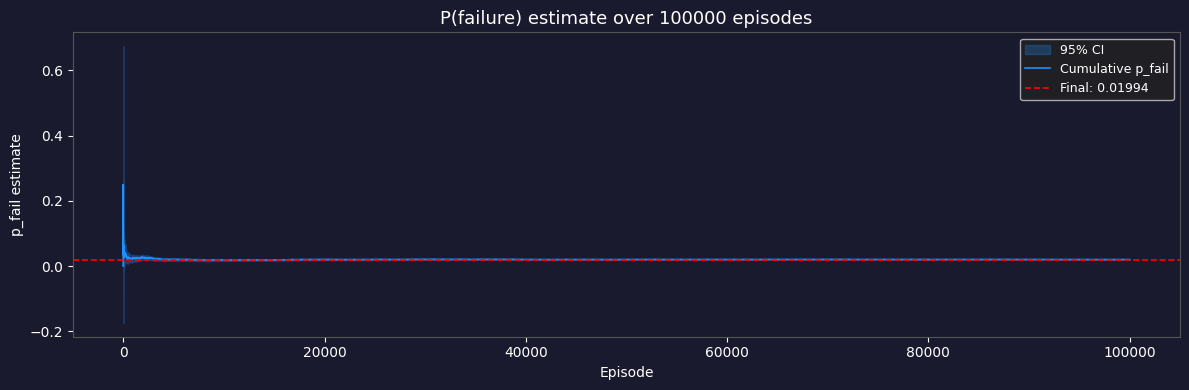

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load collision episode indices saved by eval_merge_ppo.py
collision_episode_indices = np.load("../../collision_episode_indices.npy")

# Reconstruct cumulative p_fail at every episode
fail_count = np.zeros(NUM_EPISODES)
fail_count[collision_episode_indices] = 1
episodes = np.arange(1, NUM_EPISODES + 1)
p_fail_over_time = np.cumsum(fail_count) / episodes

# Normal approximation 95% CI bands
margin = 1.96 * np.sqrt(p_fail_over_time * (1 - p_fail_over_time) / episodes)
ci_lo = p_fail_over_time - margin
ci_hi = p_fail_over_time + margin

DARK_BG = '#1a1a2e'

def style_ax(ax, fig):
    ax.set_facecolor(DARK_BG)
    fig.patch.set_facecolor(DARK_BG)
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#555')

# ── Plot 1: Full run ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
style_ax(ax, fig)

ax.fill_between(episodes, ci_lo, ci_hi, alpha=0.25, color='dodgerblue', label='95% CI')
ax.plot(episodes, p_fail_over_time, color='dodgerblue', lw=1.2, label='Cumulative p_fail')
ax.axhline(p_fail, ls='--', color='red', lw=1.2, label=f'Final: {p_fail:.5f}')

ax.set_xlabel('Episode')
ax.set_ylabel('p_fail estimate')
ax.set_title(f'P(failure) estimate over {NUM_EPISODES} episodes', fontsize=13)
ax.legend(facecolor='#222', labelcolor='white', fontsize=9)
plt.tight_layout()
plt.savefig("p_fail_over_time.png", dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


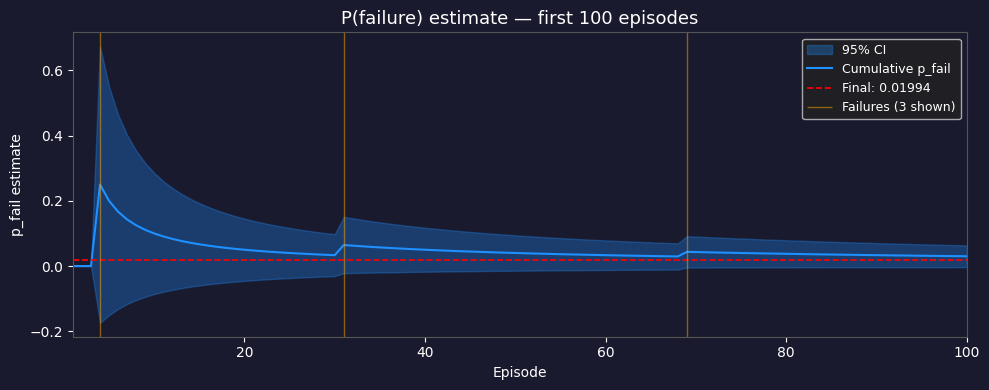

In [4]:
# ── Plot 2: First 100 episodes ─────────────────────────────────────────────
N_EARLY = 100
fig1, ax1 = plt.subplots(figsize=(10, 4))
style_ax(ax1, fig1)

ax1.fill_between(episodes[:N_EARLY], ci_lo[:N_EARLY], ci_hi[:N_EARLY],
                 alpha=0.3, color='dodgerblue', label='95% CI')
ax1.plot(episodes[:N_EARLY], p_fail_over_time[:N_EARLY],
         color='dodgerblue', lw=1.5, label='Cumulative p_fail')
ax1.axhline(p_fail, ls='--', color='red', lw=1.2, label=f'Final: {p_fail:.5f}')

early_fails = collision_episode_indices[collision_episode_indices < N_EARLY]
ax1.vlines(early_fails + 1, 0, 1, transform=ax1.get_xaxis_transform(),
           color='orange', alpha=0.5, lw=1, label=f'Failures ({len(early_fails)} shown)')

ax1.set_xlim(1, N_EARLY)
ax1.set_xlabel('Episode')
ax1.set_ylabel('p_fail estimate')
ax1.set_title('P(failure) estimate — first 100 episodes', fontsize=13)
ax1.legend(facecolor='#222', labelcolor='white', fontsize=9)
plt.tight_layout()
plt.savefig("p_fail_early.png", dpi=150, bbox_inches='tight', facecolor=fig1.get_facecolor())
plt.show()


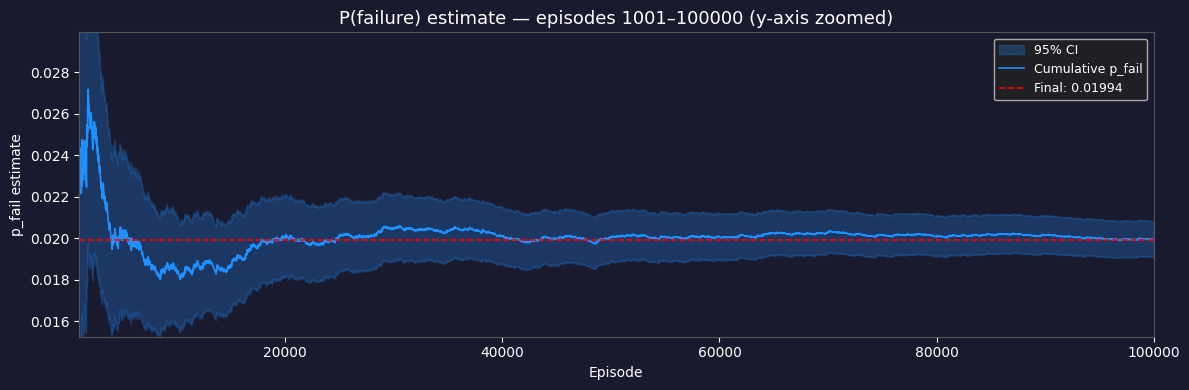

In [5]:
# ── Plot 3: Full run, y-axis zoomed ────────────────────────────────────────
SKIP = 1000
y_vals = p_fail_over_time[SKIP:]
y_pad = (y_vals.max() - y_vals.min()) * 0.3 or 0.001
y_lo = max(0, y_vals.min() - y_pad)
y_hi = y_vals.max() + y_pad

fig2, ax2 = plt.subplots(figsize=(12, 4))
style_ax(ax2, fig2)

ax2.fill_between(episodes[SKIP:], ci_lo[SKIP:], ci_hi[SKIP:],
                 alpha=0.25, color='dodgerblue', label='95% CI')
ax2.plot(episodes[SKIP:], p_fail_over_time[SKIP:],
         color='dodgerblue', lw=1.2, label='Cumulative p_fail')
ax2.axhline(p_fail, ls='--', color='red', lw=1.2, label=f'Final: {p_fail:.5f}')

ax2.set_ylim(y_lo, y_hi)
ax2.set_xlim(episodes[SKIP], episodes[-1])
ax2.set_xlabel('Episode')
ax2.set_ylabel('p_fail estimate')
ax2.set_title(f'P(failure) estimate — episodes {SKIP+1}–{NUM_EPISODES} (y-axis zoomed)', fontsize=13)
ax2.legend(facecolor='#222', labelcolor='white', fontsize=9)
plt.tight_layout()
plt.savefig("p_fail_zoomed_y.png", dpi=150, bbox_inches='tight', facecolor=fig2.get_facecolor())
plt.show()


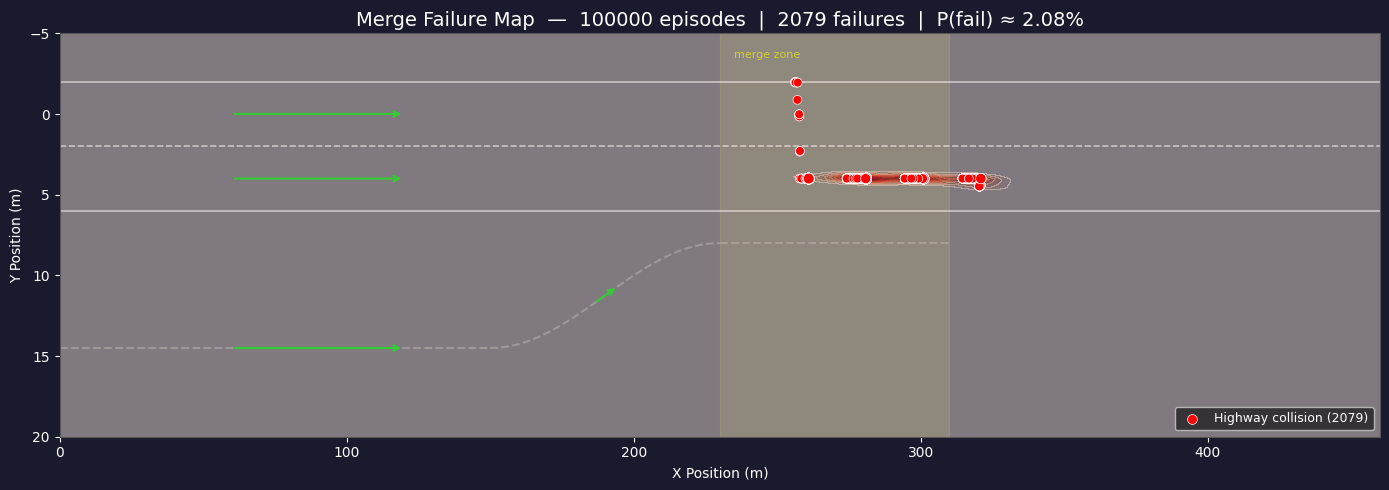

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

# Road geometry (from merge_env.py)
LANE_W = 4.0
ends = [150, 80, 80, 150]
x_total = sum(ends)  # 460m

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

# --- Road geometry ---
# Highway lane boundaries (solid=outer, dashed=center divider)
for y, ls in [(-LANE_W/2, '-'), (LANE_W/2, '--'), (LANE_W + LANE_W/2, '-')]:
    ax.axhline(y, color='white', lw=1.2, ls=ls, alpha=0.6)

# Merge zone shading (x=230 to 310)
ax.axvspan(sum(ends[:2]), sum(ends[:3]), alpha=0.12, color='yellow', zorder=1)
ax.text(sum(ends[:2]) + 5, -3.5, 'merge zone', color='yellow', alpha=0.6, fontsize=8)

# Merge ramp: straight section x=0..150 at y=14.5
ax.plot([0, ends[0]], [14.5, 14.5], color='#888', lw=1.5, ls='--', alpha=0.5)

# Sine curve x=150..230 curving from y=14.5 down to y=8
x_sine = np.linspace(ends[0], sum(ends[:2]), 100)
y_sine = 11.25 + 3.25 * np.sin(np.pi / ends[1] * (x_sine - ends[0]) + np.pi / 2)
ax.plot(x_sine, y_sine, color='#888', lw=1.5, ls='--', alpha=0.5)

# Merge ramp straight section x=230..310 at y~8
ax.plot([sum(ends[:2]), sum(ends[:3])], [8.0, 8.0], color='#888', lw=1.5, ls='--', alpha=0.5)

# --- Direction arrows ---
arrow_kw = dict(arrowstyle='->', color='limegreen', lw=1.5)
# Highway flow (two lanes)
for lane_y in [0.0, LANE_W]:
    ax.annotate('', xy=(120, lane_y), xytext=(60, lane_y),
                arrowprops=dict(**arrow_kw), zorder=4)
# Merge ramp flow (straight section)
ax.annotate('', xy=(120, 14.5), xytext=(60, 14.5),
            arrowprops=dict(**arrow_kw), zorder=4)
# Merge ramp flow (along sine curve, at midpoint)
mid = len(x_sine) // 2
ax.annotate('', xy=(x_sine[mid+5], y_sine[mid+5]), xytext=(x_sine[mid-5], y_sine[mid-5]),
            arrowprops=dict(**arrow_kw), zorder=4)

# --- KDE heatmap (only if enough points) ---
if len(collision_positions) >= 5:
    pts = np.array(collision_positions).T
    kde = gaussian_kde(pts, bw_method=0.4)
    xi = np.linspace(0, x_total, 400)
    yi = np.linspace(-5, 20, 150)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
    ax.contourf(Xi, Yi, Zi, levels=12, cmap='Reds', alpha=0.45, zorder=2)
else:
    ax.text(x_total / 2, 10, f'Need more failures for KDE\n(have {len(collision_positions)})',
            ha='center', color='white', alpha=0.5, fontsize=9)

# --- Scatter collision points ---
if collision_positions:
    xs = [p[0] for p in collision_positions]
    ys = [p[1] for p in collision_positions]
    sizes = [max(40, s * 3) for s in collision_speeds]  # larger dot = faster at crash

    merger_idx  = [i for i, t in enumerate(collision_types) if t == 'merger']
    highway_idx = [i for i, t in enumerate(collision_types) if t == 'highway']

    if merger_idx:
        ax.scatter([xs[i] for i in merger_idx], [ys[i] for i in merger_idx],
                   s=[sizes[i] for i in merger_idx], c='dodgerblue', zorder=5,
                   edgecolors='white', lw=0.5, label=f'Merger collision ({len(merger_idx)})')
    if highway_idx:
        ax.scatter([xs[i] for i in highway_idx], [ys[i] for i in highway_idx],
                   s=[sizes[i] for i in highway_idx], c='red', zorder=5,
                   edgecolors='white', lw=0.5, label=f'Highway collision ({len(highway_idx)})')

ax.set_xlim(0, x_total)
ax.set_ylim(-5, 20)
ax.invert_yaxis()  # match highway-env screen coords (y increases downward)
ax.set_xlabel('X Position (m)', color='white')
ax.set_ylabel('Y Position (m)', color='white')
ax.set_title(
    f'Merge Failure Map  —  {NUM_EPISODES} episodes  |  {failures} failures  |  P(fail) ≈ {p_fail*100:.2f}%',
    color='white', fontsize=14
)
ax.tick_params(colors='white')
ax.legend(loc='lower right', facecolor='#222', labelcolor='white', fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#555')

plt.tight_layout()
plt.savefig("merge_failure_map.png", dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()